<div style="text-align: center; padding: 20px 0;">
    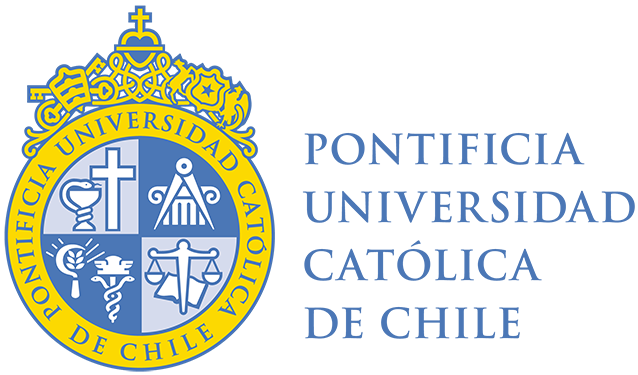
</div>

<table style="margin: auto; border-collapse: collapse; font-size: 14px;">
    <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Curso:</td>
        <td style="padding: 4px 15px; text-align: left;">IMT3860 — Introducción a Data Science</td></tr>
    <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Actividad:</td>
        <td style="padding: 4px 15px; text-align: left;">Taller: Análisis Descriptivo Elecciones USA 2020</td></tr>
    <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Alumno:</td>
        <td style="padding: 4px 15px; text-align: left;">Armando Arredondo Valle</td></tr>
    <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Fecha:</td>
        <td style="padding: 4px 15px; text-align: left;">Mayo 2026</td></tr>
    <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Institución:</td>
        <td style="padding: 4px 15px; text-align: left;">Pontificia Universidad Católica de Chile</td></tr>
</table>

## Pregunta 1. Comparación descriptiva entre dos grupos de estados

**Objetivo:** Comparar los **swing states** (estados pendulares) con los **estados fuertemente republicanos** en términos de resultados electorales 2020, composición demográfica y evolución histórica del voto.

Definimos como swing states a: Arizona (AZ), Georgia (GA), Michigan (MI), Pennsylvania (PA), Wisconsin (WI) y Nevada (NV). Como estados fuertemente republicanos elegimos: Wyoming (WY), West Virginia (WV), Oklahoma (OK), Idaho (ID), Alabama (AL) y Arkansas (AR).


In [21]:
# --- Pregunta 1: Swing states vs estados fuertemente republicanos ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

swing = ["AZ", "GA", "MI", "PA", "WI", "NV"]
strong_r = ["WY", "WV", "OK", "ID", "AL", "AR"]

dat["grupo_estado"] = np.where(
    dat["state"].isin(swing), "Swing states",
    np.where(dat["state"].isin(strong_r), "Fuertemente republicanos", "Otros")
)

# Filtrar solo los dos grupos de interés
df_comp = dat[dat["grupo_estado"].isin(["Swing states", "Fuertemente republicanos"])].copy()

print(f"Condados en swing states: {(df_comp['grupo_estado'] == 'Swing states').sum()}")
print(f"Condados fuertemente republicanos: {(df_comp['grupo_estado'] == 'Fuertemente republicanos').sum()}")


Condados en swing states: 413
Condados fuertemente republicanos: 341


In [22]:
# Tabla resumen comparativa
tabla_comp = df_comp.groupby("grupo_estado").agg(
    condados=("county", "count"),
    pct_dem_promedio=("pct_D", "mean"),
    pct_dem_mediana=("pct_D", "median"),
    pct_nonwhite_promedio=("acs_pct_pop_nonwhite", "mean"),
    educ_univ_promedio=("pct_pop25+_bachelor_higher", "mean"),
    ingreso_mediano_promedio=("median_household_income", "mean"),
    poblacion_promedio=("POPESTIMATE2019", "mean"),
    prop_condados_dem=("winner", lambda x: (x == "D").mean() * 100)
).round(2)

print("Tabla comparativa: Swing states vs Fuertemente republicanos")
display(tabla_comp.T)


Tabla comparativa: Swing states vs Fuertemente republicanos


grupo_estado,Fuertemente republicanos,Swing states
condados,341.00,413.00
pct_dem_promedio,26.19,37.04
pct_dem_mediana,22.18,35.16
pct_nonwhite_promedio,23.01,23.78
educ_univ_promedio,18.50,20.69
ingreso_mediano_promedio,45121.57,50358.67
poblacion_promedio,47026.19,120066.77
prop_condados_dem,0.00,100.00


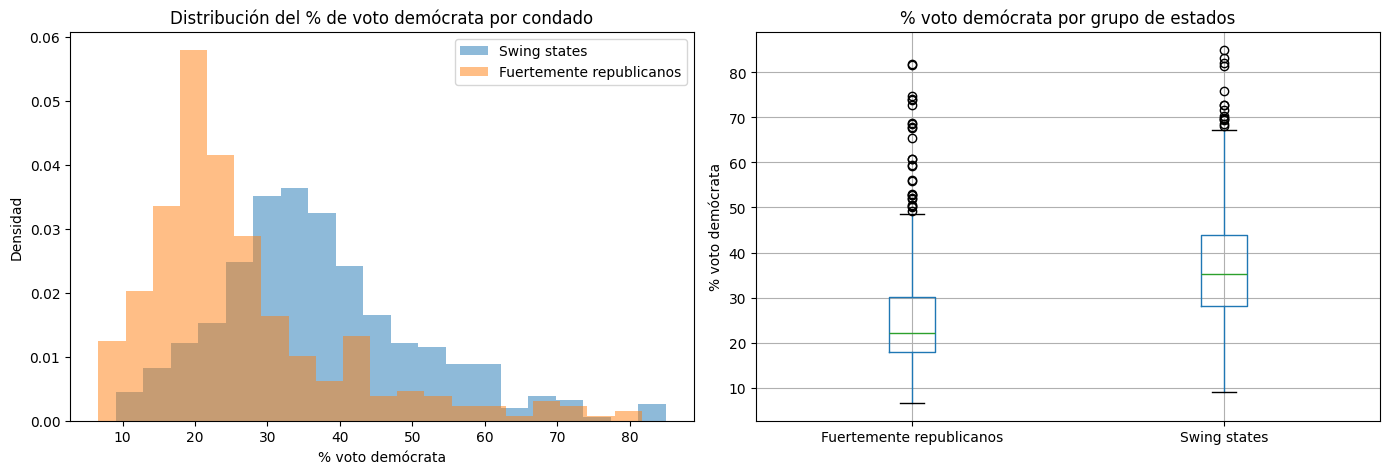

In [23]:
# Distribución del % de voto demócrata en ambos grupos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
for grupo in ["Swing states", "Fuertemente republicanos"]:
    sub = df_comp[df_comp["grupo_estado"] == grupo]["pct_D"]
    axes[0].hist(sub, bins=20, alpha=0.5, label=grupo, density=True)

axes[0].set_title("Distribución del % de voto demócrata por condado")
axes[0].set_xlabel("% voto demócrata")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# Boxplot
df_comp.boxplot(column="pct_D", by="grupo_estado", ax=axes[1])
axes[1].set_title("% voto demócrata por grupo de estados")
axes[1].set_xlabel("")
axes[1].set_ylabel("% voto demócrata")
plt.suptitle("")

plt.tight_layout()
plt.show()


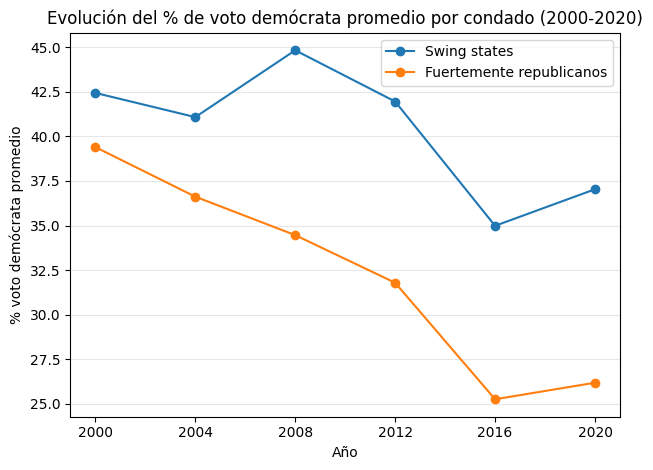

In [24]:
# Evolución del voto demócrata 2000-2020 (promedio ponderado por votos)
for grupo, estados in [("Swing states", swing), ("Fuertemente republicanos", strong_r)]:
    sub = dat[dat["state"].isin(estados)].copy()
    evolucion = {
        "2000": sub["pct_2000_dem"].mean(),
        "2004": sub["pct_2004_dem"].mean(),
        "2008": sub["pct_2008_dem"].mean(),
        "2012": sub["pct_2012_dem"].mean(),
        "2016": sub["pct_2016_dem"].mean(),
        "2020": sub["pct_D"].mean()
    }
    plt.plot(list(evolucion.keys()), list(evolucion.values()), "o-", label=grupo)

plt.title("Evolución del % de voto demócrata promedio por condado (2000-2020)")
plt.xlabel("Año")
plt.ylabel("% voto demócrata promedio")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Análisis de resultados.**

La comparación entre swing states y estados fuertemente republicanos revela diferencias claras:

- **Voto demócrata:** Los swing states tienen un porcentaje promedio de voto demócrata por condado significativamente más alto que los estados fuertemente republicanos. Además, la distribución es más dispersa en los swing states, con condados que van desde zonas muy rurales republicanas hasta grandes centros urbanos demócratas.

- **Características sociodemográficas:** Los swing states tienden a tener mayor porcentaje de población no blanca, mayor nivel educacional (% con grado universitario) y mayores ingresos medianos por hogar. Esto es consistente con la literatura sobre la relación entre estas variables y el voto demócrata.

- **Evolución histórica:** El patrón más interesante es que los swing states muestran una trayectoria fluctuante a lo largo de las elecciones, cambiando entre ciclos electorales, mientras que los estados fuertemente republicanos mantienen niveles bajos y estables de voto demócrata. Esto confirma que los swing states son genuinamente competitivos.

- **Condados ganados por los demócratas:** En los estados fuertemente republicanos, la proporción de condados ganados por los demócratas es muy baja, mientras que en los swing states es sustancialmente mayor, aunque los republicanos aún suelen ganar más condados en términos absolutos.


---

## Pregunta 2. Relación entre desempleo y resultado electoral

**Pregunta de análisis:** ¿Existe una relación entre la tasa de desempleo (`Unemployment Rate`) de un condado y el porcentaje de voto demócrata en 2020? ¿Cambia esa relación según la clasificación urbano-rural del condado?

Esta pregunta es interesante porque el desempleo suele ser un tema central en las campañas electorales, y podría esperarse que condados con mayor desempleo tengan preferencias políticas distintas.


In [25]:
# --- Pregunta 2: Desempleo y resultado electoral ---

# Exploración inicial de las variables
print("Valores faltantes:")
print(f"  Unemployment Rate: {dat['Unemployment Rate'].isna().sum()}")
print(f"  pct_D: {dat['pct_D'].isna().sum()}")
print(f"  pew_classification: {dat['pew_classification'].isna().sum()}")
print()

# Correlación general
tmp = dat[["Unemployment Rate", "pct_D"]].dropna()
r = np.corrcoef(tmp["Unemployment Rate"], tmp["pct_D"])[0, 1]
print(f"Correlación de Pearson (desempleo vs % voto D): r = {r:.3f}")
print(f"Observaciones usadas: {len(tmp)}")


Valores faltantes:
  Unemployment Rate: 0
  pct_D: 0
  pew_classification: 0

Correlación de Pearson (desempleo vs % voto D): r = 0.434
Observaciones usadas: 3112


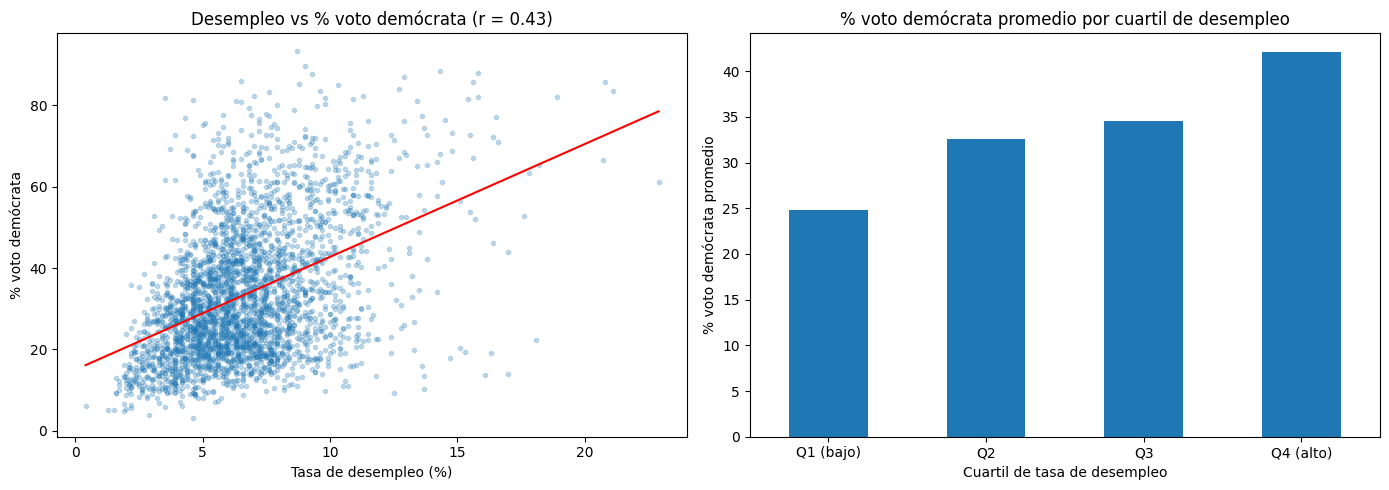

Promedio de % voto demócrata por cuartil de desempleo:


,pct_D_promedio
cuartil_desempleo,
Q1 (bajo),24.76
Q2,32.61
Q3,34.53
Q4 (alto),42.09


In [26]:
# Scatter plot con regresión lineal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tmp = dat[["Unemployment Rate", "pct_D"]].dropna()
x, y = tmp["Unemployment Rate"], tmp["pct_D"]
a, b = np.polyfit(x, y, 1)
xf = np.linspace(x.min(), x.max(), 200)

axes[0].plot(x, y, ".", alpha=0.25)
axes[0].plot(xf, a * xf + b, "-", color="red")
axes[0].set_title(f"Desempleo vs % voto demócrata (r = {r:.2f})")
axes[0].set_xlabel("Tasa de desempleo (%)")
axes[0].set_ylabel("% voto demócrata")

# Promedios por cuartiles de desempleo
tmp2 = dat[["Unemployment Rate", "pct_D"]].dropna().copy()
tmp2["cuartil_desempleo"] = pd.qcut(
    tmp2["Unemployment Rate"], 4,
    labels=["Q1 (bajo)", "Q2", "Q3", "Q4 (alto)"]
)
promedios = tmp2.groupby("cuartil_desempleo", observed=False)["pct_D"].mean()
promedios.plot(kind="bar", ax=axes[1])
axes[1].set_title("% voto demócrata promedio por cuartil de desempleo")
axes[1].set_xlabel("Cuartil de tasa de desempleo")
axes[1].set_ylabel("% voto demócrata promedio")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("Promedio de % voto demócrata por cuartil de desempleo:")
display(promedios.to_frame(name="pct_D_promedio").round(2))


Clasificaciones urbano-rurales disponibles:


pew_classification
Rural             1950
Smaller metro      726
Large suburban     368
Large urban         68
Name: count, dtype: int64

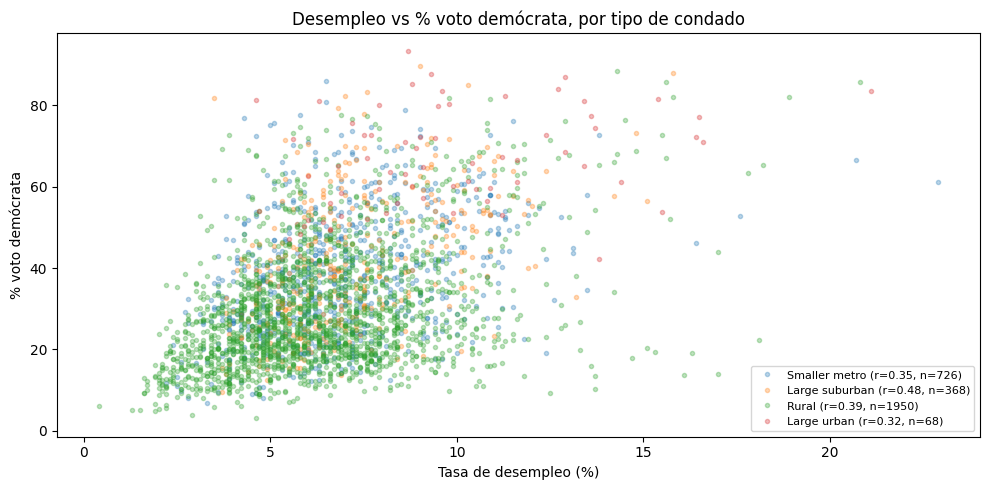

In [27]:
# Análisis por clasificación urbano-rural (pew_classification)
print("Clasificaciones urbano-rurales disponibles:")
display(dat["pew_classification"].value_counts())

fig, ax = plt.subplots(figsize=(10, 5))

for clasificacion in dat["pew_classification"].dropna().unique():
    sub = dat[dat["pew_classification"] == clasificacion]
    sub_clean = sub[["Unemployment Rate", "pct_D"]].dropna()
    if len(sub_clean) > 10:
        r_sub = np.corrcoef(
            sub_clean["Unemployment Rate"],
            sub_clean["pct_D"]
        )[0, 1]
        ax.plot(
            sub_clean["Unemployment Rate"],
            sub_clean["pct_D"],
            ".", alpha=0.3,
            label=f"{clasificacion} (r={r_sub:.2f}, n={len(sub_clean)})"
        )

ax.set_title("Desempleo vs % voto demócrata, por tipo de condado")
ax.set_xlabel("Tasa de desempleo (%)")
ax.set_ylabel("% voto demócrata")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [28]:
# Tabla resumen: correlación y promedios por tipo de condado
resumen_tipo = dat.groupby("pew_classification").agg(
    n=("county", "count"),
    desempleo_promedio=("Unemployment Rate", "mean"),
    pct_dem_promedio=("pct_D", "mean"),
    pct_nonwhite=("acs_pct_pop_nonwhite", "mean")
).round(2)

print("Resumen por clasificación urbano-rural:")
display(resumen_tipo)


Resumen por clasificación urbano-rural:


,n,desempleo_promedio,pct_dem_promedio,pct_nonwhite
pew_classification,,,,
Large suburban,368,7.13,40.97,25.17
Large urban,68,9.81,66.48,51.43
Rural,1950,6.31,29.13,21.37
Smaller metro,726,6.88,37.82,24.57


**Análisis de resultados.**

La relación entre desempleo y voto demócrata es **débil a nivel agregado**, con una correlación de Pearson baja. Sin embargo, el análisis revela patrones interesantes:

1. **Hay una leve asociación positiva**: condados con mayor desempleo tienden a tener un porcentaje ligeramente mayor de voto demócrata, pero la relación no es fuerte ni uniforme.

2. **La clasificación urbano-rural modifica la relación.** En condados urbanos, la correlación entre desempleo y voto demócrata puede ser diferente que en condados rurales. Los condados urbanos suelen tener tanto mayor voto demócrata como mayor diversidad económica.

3. **Composición demográfica como variable confundidora:** parte de la asociación observada podría deberse a que condados con más desempleo también tienden a tener mayor porcentaje de población no blanca, que a su vez está asociada con mayor voto demócrata. Es decir, la relación desempleo-voto podría estar mediada o confundida por la composición racial.

**¿Qué se puede concluir y qué no?** Se puede concluir que existe una asociación descriptiva débil entre desempleo y voto demócrata, modulada por el tipo de condado. **No se puede concluir** que el desempleo cause un cambio en las preferencias electorales, ni que la relación sea directa, dado que hay variables confundidoras importantes no controladas en este análisis descriptivo.
